<a href="https://colab.research.google.com/github/chika4895-a11y/Demo1/blob/main/transfer_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Step 2: Set Dataset Paths
import os

In [ ]:
# Update this path to match where your dataset is inside your Google Drive
base_dir = '/content/drive/MyDrive/our plant village'


In [ ]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')


In [ ]:
# Step 3: Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [ ]:
# Step 4: Image Data Generators
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 2546 images belonging to 4 classes.
Found 635 images belonging to 4 classes.


In [ ]:
# Step 5: Load Pretrained Model - MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
preds = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Step 6: Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Train the Model
EPOCHS = 50
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 637s 8s/step - accuracy: 0.6699 - loss: 0.9183 - val_accuracy: 0.9354 - val_loss: 0.2348
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 495ms/step - accuracy: 0.9170 - loss: 0.2622 - val_accuracy: 0.9559 - val_loss: 0.1677
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 490ms/step - accuracy: 0.9453 - loss: 0.1764 - val_accuracy: 0.9669 - val_loss: 0.1194
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 491ms/step - accuracy: 0.9637 - loss: 0.1257 - val_accuracy: 0.9606 - val_loss: 0.1206
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 488ms/step - accuracy: 0.9756 - loss: 0.1024 - val_accuracy: 0.9748 - val_loss: 0.0850
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 486ms/step - accuracy: 0.9659 - loss: 0.0934 - val_accuracy: 0.9764 - val_loss: 0.0786
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 490ms/step - accuracy: 0.9730 - loss: 0.0893 - val_accuracy: 0.9827 - val_loss: 0.0752
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 489ms/step - accuracy: 0.9800 - loss: 0.0691 - val_accura

In [ ]:
# Step 8: Evaluate
val_data.reset()
predictions = model.predict(val_data, verbose=1)
y_pred = predictions.argmax(axis=1)

print("Classification Report:")
print(classification_report(val_data.classes, y_pred, target_names=val_data.class_indices.keys()))

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step
Classification Report:
                          precision    recall  f1-score   support

      Apple___Apple_scab       0.99      0.98      0.98       126
       Apple___Black_rot       0.99      0.99      0.99       125
Apple___Cedar_apple_rust       1.00      1.00      1.00        55
         Apple___healthy       0.99      1.00      0.99       329

                accuracy                           0.99       635
               macro avg       0.99      0.99      0.99       635
            weighted avg       0.99      0.99      0.99       635



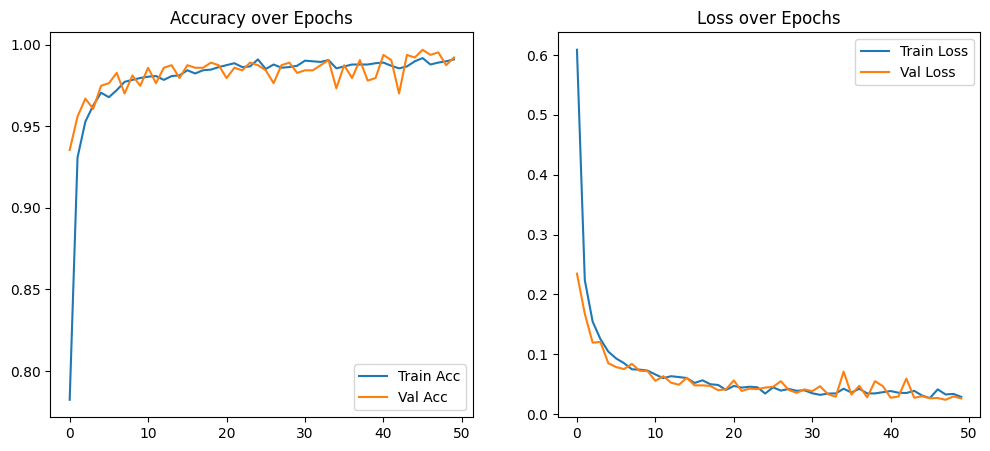

In [ ]:
# Step 9: Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()
